<a href="https://colab.research.google.com/github/auliatauhid/Data-Science-2026/blob/main/Pertemuan11_AuliaTauhid_250401020136.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


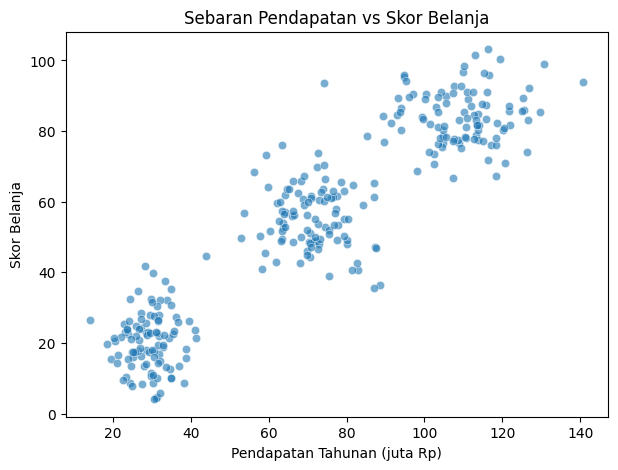

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling     :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


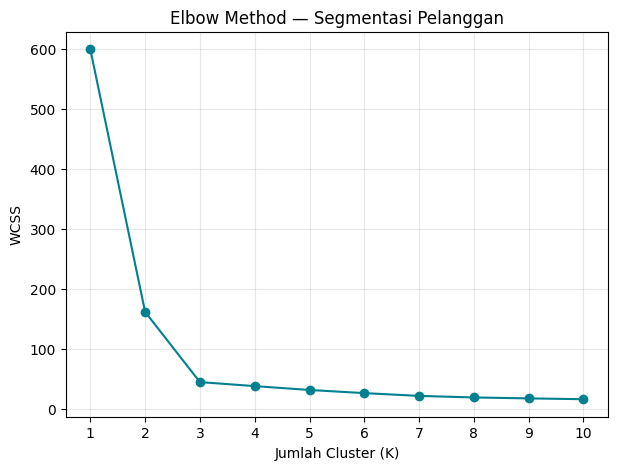

In [6]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

# Interpretasi:
# - Kurva WCSS mulai melandai signifikan di sekitar K = 3 (titik elbow).
# - Hasil ini sesuai dengan asumsi awal dataset yang memang dibangun
#   dari 3 kelompok tersembunyi (hemat, menengah, boros).

In [7]:
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir      : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


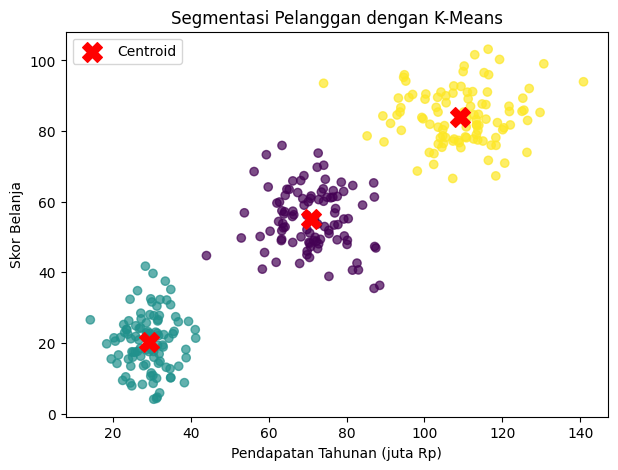

In [8]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

# Interpretasi tiap cluster:
# Cluster 0 = pendapatan rendah, belanja rendah   -> segmen 'Hemat'
# Cluster 1 = pendapatan menengah, belanja menengah -> segmen 'Menengah'
# Cluster 2 = pendapatan tinggi, belanja tinggi   -> segmen 'Boros/Premium'
# (urutan label 0/1/2 bisa berbeda tergantung inisialisasi K-Means;
#  cek groupby mean di Langkah 4 untuk memastikan label mana yang cocok
#  dengan karakteristik mana)

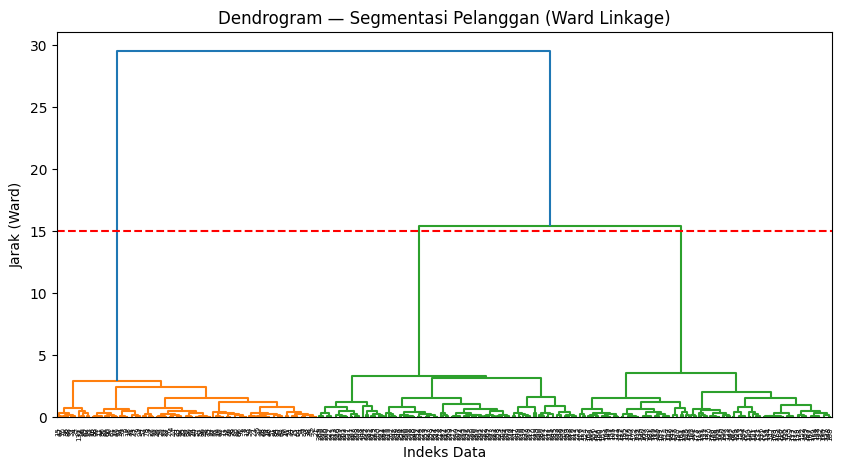

Silhouette Score (Hierarchical): 0.694
Silhouette Score (K-Means)     : 0.695

Adjusted Rand Index (K-Means vs Hierarchical): 0.990

Rata-rata fitur per cluster (Hierarchical):
                      pendapatan_tahunan  skor_belanja
cluster_hierarchical                                  
1                                  29.45         20.51
2                                 109.20         84.08
3                                  71.27         55.16

Crosstab K-Means vs Hierarchical:
Hierarchical    1    2   3
KMeans                    
0               1    0  98
1             100    0   0
2               0  101   0


In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--')  # contoh garis potong
plt.show()

# Bandingkan: apakah jumlah cluster dari dendrogram (garis potong)
# konsisten dengan K optimal hasil Metode Elbow pada Langkah 3?
#
# Kesimpulan:
# Garis potong horizontal pada jarak Ward ≈ 15 memotong dendrogram menjadi
# 3 cabang utama. Jumlah ini KONSISTEN dengan K optimal (K=3) yang diperoleh
# dari titik elbow pada Metode Elbow di Langkah 3.
#
# Artinya, dua pendekatan clustering yang berbeda — K-Means (partitional,
# berbasis minimisasi WCSS) dan Hierarchical Clustering (agglomerative,
# berbasis jarak Ward) — sama-sama mengarah pada struktur yang sama:
# data pelanggan terbagi menjadi 3 segmen alami, yaitu:
#   1. Hemat        -> pendapatan & skor belanja rendah
#   2. Menengah      -> pendapatan & skor belanja menengah
#   3. Boros/Premium -> pendapatan & skor belanja tinggi
#
# Kesesuaian ini memperkuat validitas hasil segmentasi, karena tidak
# hanya bergantung pada satu algoritma saja, melainkan didukung oleh
# dua metode clustering yang independen.

# --- Bukti kuantitatif tambahan ---
hier_labels = fcluster(Z, t=3, criterion='maxclust')
df['cluster_hierarchical'] = hier_labels

sil_hier = silhouette_score(X_scaled, hier_labels)
print(f'Silhouette Score (Hierarchical): {sil_hier:.3f}')
print(f'Silhouette Score (K-Means)     : {silhouette_score(X_scaled, model.labels_):.3f}')

ari = adjusted_rand_score(df['cluster'], df['cluster_hierarchical'])
print(f'\nAdjusted Rand Index (K-Means vs Hierarchical): {ari:.3f}')

print('\nRata-rata fitur per cluster (Hierarchical):')
print(df.groupby('cluster_hierarchical')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

print('\nCrosstab K-Means vs Hierarchical:')
print(pd.crosstab(df['cluster'], df['cluster_hierarchical'],
                   rownames=['KMeans'], colnames=['Hierarchical']))